# 🐍 Guía de Migración: MATLAB → Python

Este notebook está diseñado para estudiantes que ya conocen **MATLAB** y quieren aprender **Python** para ciencia de datos, ingeniería y computación numérica.

**Objetivo:** Mostrar las similitudes y diferencias de sintaxis entre ambos lenguajes, función por función.

---

In [21]:
import numpy as np          # Equivalente a las matrices de MATLAB
import matplotlib.pyplot as plt  # Equivalente a plotting de MATLAB
import pandas as pd         # Manejo de datos (similar a tablas de MATLAB)
import time

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Migrando de Matlab a Python
### Tipos de datos en Python

Los tipos de datos son la base fundamental para organizar y manipular la información en los lenguajes de programación. Cierto tipo de dato define el tipo de valor que se puede manejar y las operaciones que se pueden realizar con ese tipo de dato.

Los tipos de datos primitivos son los tipos de datos más básicos que ofrece un lenguaje de programación. Son indivisibles y solo pueden almacenar un único valor. Los tipos de datos primitivos más comunes incluyen:

<div style="display: flex; justify-content: center;">

| Categoría | Tipo de Dato | Descripción |                  Ejemplos                   |
| :---: | :---: | :--- |:-------------------------------------------:|
| Tipo Numérico | Entero (int)| Números enteros positivos, negativos o cero. Comprende un rango de valores aproximadamente de -9,223,372,036,854,775,808 a 9,223,372,036,854,775,807. |            ```1, -10, 0, 200```             |
| Tipo Numérico | Número Flotante (float) | Números de punto flotante. Comprende un rango de valores aproximadamente de ±1.79769313486231570E+308 (precisión de 15-16 dígitos decimales). |       ```3.1416, -5.2, 10.0, 0.33```        |
| Tipo Texto | Cadena de Texto (str) | Secuencias de caracteres. | ```"Hola mundo", "Python es genial", "42"``` | Suma total de caracteres |
| Tipo booleano | Booleano (bool) | Valores de verdad o falso. |              ```True, False```              |

</div>

### Nombrar variables en Python
Nombrar adecuadamente a una variable permite saber con facilidad que dato contiene almacenado. Utilizar nombres descriptivos ayuda a que nuestro código sea facil de _leer_ y _entender_.

A una variable se le puede nombrar de cualquier manera, pero Python tiene ciertas restricciones sobre los nombres de las variables. Mientras sigas las siguientes reglas, se puede nombrar a una variable de la mejor manera que consideremos:

* El nombre de una variable tiene que ser sólo una palabra sin espacios.
* Se pueden usar solamente letras, números y el caracter `_` para formar los nombres de las variables.
* El nombre de una variable no puede empezar con un número.

<div style="display: flex; justify-content: center;">

| Nombre de variables válidos | Nombre de variables No válidos |
| --- | --- |
| balance_actual | balance-actual (el guión `-` no es permitido) |
| balanceActual | balance actual (los espacios no están permitidos) |
| cuenta4 | 4cuenta (un nombre no puede empezar con un número) |
| SUMA_TOTAL | \$UMA_TOTAL (caracteres especiales como `$` no son permitidos) |
| _45 (no recomendado, no es un nombre descriptivo) | 45_ (un nombre no puede empezar con un número) |
| saludo | 'saludo' (caracteres especiales como `'` no están permitidos) |

</div>

### Tabla de Equivalencias Rápidas
<div style="display: flex; justify-content: center;">

| Concepto     | MATLAB             | Python (NumPy)            |
|:-------------|:-------------------|:--------------------------|
| Comentario   | `% comentario`     | `# comentario`            |
| Fin de línea | `;` suprime output | implícito, o `;` opcional |
| Rango        | `1:10`             | `np.arange(1, 11)`        |
| Matriz ceros | `zeros(3,3)`       | `np.zeros((3,3))`         |
| Matriz unos  | `ones(3,3)`        | `np.ones((3,3))`          |
| Identidad    | `eye(3)`           | `np.eye(3)`               |
| Aleatorio    | `rand(3,3)`        | `np.random.rand(3,3)`     |
| Transpuesta  | `A'`               | `A.T` o `np.transpose(A)` |
| Inversa      | `inv(A)`           | `np.linalg.inv(A)`        |
| Autovalores  | `eig(A)`           | `np.linalg.eig(A)`        |
| Tamaño       | `size(A)`          | `A.shape`                 |
| Longitud     | `length(v)`        | `len(v)` o `v.size`       |

</div>

## 1. Estructuras de Control

### Bucles y condicionales

In [5]:
# Bucle for
# ============================================================
# MATLAB:
#
# for i = 1:10
#   disp(i)
# end
#
# ============================================================
# Python:
for i in range(1, 11):  # range(1, 11) = 1 al 10 (el 11 es exclusivo)
    print(i, end=' ')

1 2 3 4 5 6 7 8 9 10 

In [6]:
# Bucle while
# ============================================================
# MATLAB:
#
# count = 1;
# while count <= 5
#     disp(count);
#     count = count + 1;
# end
#
# ============================================================
# Pyhon:
count = 1
while count <= 5:
    print(count, end=' ')
    count += 1

1 2 3 4 5 

In [7]:
# Estructura Condicional
# ============================================================
# MATLAB:
#
# if x > 0
#     disp('positivo')
# elseif x < 0
#     disp('negativo')
# else
#     disp('cero')
# end
#
# ============================================================
# Python
x = -5
print(f'x = {x}')
if x > 0:
    print('x es positivo')
elif x < 0:
    print('x es negativo')
else:
    print('x es cero')

x = -5
x es negativo


In [8]:
# Lista comprimida.
# Esta estructura:
cuadrados = [x**2 for x in range(1, 11)]
print('Cuadrados (1-10):', cuadrados)

# es equivalente a:
cuadrados = []
for x in range(1,11):
    cuadrados.append(x**2)
print('Cuadrados (1-10):', cuadrados)


Cuadrados (1-10): [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
Cuadrados (1-10): [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


## 2. Definición de Funciones

### Crear funciones reutilizables

In [13]:
# ============================================================
# MATLAB:  function [y, z] = miFuncion(a, b)
#              y = a + b;
#              z = a * b;
#          end
# ============================================================

# En Python usamos 'def'
def mi_funcion(a, b):
    """
    Calcula suma y producto de dos números.
    
    Parámetros:
        a, b: números
    
    Retorna:
        tuple: (suma, producto)
    """
    y = a + b
    z = a * b
    return y, z

# Uso
suma, producto = mi_funcion(5, 3)
print(f'Suma: {suma}, Producto: {producto}')
print()

# Función con valores por defecto (similar a MATLAB)
def greet(name, greeting='Hola'):
    """Función con parámetro opcional."""
    return f'{greeting}, {name}!'

print(greet('Mundo'))
print(greet('Mundo', 'Hello'))
print()

# Aplicar función a array
def f(x):
    return x**2 + 2*x + 1

vector = np.array([1, 2, 3, 4, 5])
resultado = np.vectorize(f)(vector)
print('f(vector) =', resultado)

Suma: 8, Producto: 15

Hola, Mundo!
Hello, Mundo!

f(vector) = [ 4  9 16 25 36]


### Funciones especiales de Python

#### La función `print()`

Esta función muestra en la pantalla, cualquier valor o variable que esté dentro de sus paréntesis. Por ejemplo, la siguiente expresión muestra en pantalla la siguiente cadena de texto:


In [14]:
print("¡Hola, Mundo!")

¡Hola, Mundo!


> **Nota**
> Observe que las comillas `" "` no se imprimen en pantalla, ellas se usan solo para delimitar donde empieza y termina la cadena de texto; no forman parte del texto.

Cuando Python ejecuta la expresión anterior, se dice que _Python llama a la función `print()`_ y también se dice que *la candena de texto es pasada a la función*. Un valor o variable que es pasada a una función se le conoce como *argumento*. Hay varias formas de utilizar la función `print()`, algunas de ellas son:

In [15]:
nombre = "Alfredo"
print("Es un gusto conocerte, " + nombre)
print("Es un gusto conocerte, {}".format(nombre))
print(f"Es un gusto conocerte, {nombre}")

Es un gusto conocerte, Alfredo
Es un gusto conocerte, Alfredo
Es un gusto conocerte, Alfredo



En Python (y en muchos lenguajes), escapar caracteres significa usar una secuencia especial para representar caracteres que de otra forma serían difíciles o imposibles de escribir directamente en un string.

- ¿Por qué se escapan caracteres?

    - Para escribir caracteres especiales que tienen un significado dentro de una cadena (ej. ", ', \).

    - Para incluir caracteres invisibles como salto de línea, tabulación, etc.

    - Para representar caracteres usando códigos Unicode o ASCII.

- Caracteres de escape más comunes en Python

| Secuencia | Significado           |
|-----------|-----------------------|
| \\'       | Comilla simple        |
| \\"       | Comilla doble         |
| \ \       | Barra invertida (\\)  |
| \\n       | Salto de línea        |
| \\t       | Tabulación            |
| \\b       | Backspace (retroceso) |

Veamos algunos ejemplos:


In [16]:
# Escapar comillas dobles
nombre = "Alfredo"
# print(f"Hola "{nombre}", es un gusto conocerte.")
print(f"Hola \"{nombre}\", es un gusto conocerte.")

Hola "Alfredo", es un gusto conocerte.


In [17]:
# El salto de línea
print("Esto es un\nsalto de línea")
print("="*80)
# Print por default inserta un salto de línea al final de la expresión, pero podemos cambiar este comportamiento
print("Texto sin salto de línea", end='***')
print("Texto que termina con salto de línea")
print("Línea nueva")

Esto es un
salto de línea
Texto sin salto de línea***Texto que termina con salto de línea
Línea nueva


In [18]:
# Tabulador
print("Esto es\tun tabulador")
print("Esto es\t\tun tabulador")
print("Esto es\t\t\tun tabulador")

Esto es	un tabulador
Esto es		un tabulador
Esto es			un tabulador


In [27]:
# Backspace
print("Este texto es muy largo", end=" ")
time.sleep(1)
print("\rEste texto es \bmuy largo", end=" ")
time.sleep(1)
print("\rEste texto es\bmuy largo", end=" ")
time.sleep(1)
print("\rEste texto es\b\bmuy largo", end=" ")
time.sleep(1)
print("\rEste texto es\b\b\bmuy largo", end=" ")
time.sleep(1)
print("\rEste texto es\b\b\b\bmuy largo", end=" ")
time.sleep(1)
print("\rEste texto es\b\b\b\b\bmuy largo", end=" ")



Este texmuy largo 

In [28]:
# Impresión de valores numéricos
areaCirculo = 34*np.pi*np.pi
print(f"Área del circulo: {areaCirculo}")
print(f"Área del circulo: {areaCirculo:.2f}")
print(f"Área del circulo: {areaCirculo:08.3f}")
print(f"Área del circulo: {areaCirculo:04.0f}")
print(f"Área del circulo: {areaCirculo:.2e}")

Área del circulo: 335.5665496370382
Área del circulo: 335.57
Área del circulo: 0335.567
Área del circulo: 0336
Área del circulo: 3.36e+02


#### La función `input()`

Esta función nos permite leer datos que el usuario escribe por teclado.

Se le puede pasar como parámetro un mensaje, aunque es opcional, que se muestra en pantalla antes de esperar la entrada.  Mírense estos ejemplos:

In [29]:
# Sin pasarle un mensaje como argumento
input()

'\n'

In [30]:
# Pasándole un mensaje al usuario
input("Introduce un texto o número: ")

'e\n'

Si no queremos introducir ningún valor, solo damos `enter`. La función `input()` nos devolverá una cadena texto vacía: `''`.

**Importante:** El valor que retorna siempre es un `str`(cadena de texto):

In [31]:
valor = input("Introduce un valor")
type(valor)

str

`type(variable)`
es una función que nos dice que tipo de dato almacena una variable; se le pasa como parámetro el nombre de la variable que nos interesa saber su tipo de dato.

Si queremos que la función `input()` nos devuelva un número en vez de una cadena de texto, tenemos que usar la función `int()`. A la función `int()` se le pasa como argumentos un número entero como cadena de texto("325") o un número de tipo float y nos regresa la representación numérica de esa cadena o la parte entera del número decimal:

In [32]:
# Argumento: número entero como cadena de texto
int("334")

334

In [33]:

# Argumento: número decimal
int(3.523)

3

También existe la función `float()`, a la cual se le pasa como argumentos un número decimal como cadena de texto("325.234") o un número entero y nos regresa la representación numérica de esa cadena y el número entero convertido a tipo float:

In [34]:
# Argumento: número decimal como cadena de texto
float("325.235")

325.235

In [35]:
# Argumento: número entero
float(34)

34.0

## 3. Creación de Vectores y Matrices

### MATLAB vs Python

In [36]:
# ============================================================
# MATLAB:  v = [1 2 3 4 5]          % Vector fila
#          v = [1; 2; 3; 4; 5]      % Vector columna
# ============================================================

# Python con NumPy:
v_fila = np.array([1, 2, 3, 4, 5])           # Vector fila (1D array)
v_columna = np.array([[1], [2], [3], [4], [5]])  # Vector columna (2D array)

print('Vector fila:', v_fila)
print('Shape:', v_fila.shape)
print()
print('Vector columna:')
print(v_columna)
print('Shape:', v_columna.shape)

Vector fila: [1 2 3 4 5]
Shape: (5,)

Vector columna:
[[1]
 [2]
 [3]
 [4]
 [5]]
Shape: (5, 1)


In [37]:
# ============================================================
# MATLAB:  x = 1:10                 % 1 al 10, paso 1
#          x = 1:2:10               % 1 al 10, paso 2
#          x = linspace(0, 1, 100)  % 100 puntos entre 0 y 1
# ============================================================

# Python:
x1 = np.arange(1, 11)           # 1 al 10 (el final es exclusivo!)
x2 = np.arange(1, 11, 2)        # 1 al 10, paso 2
x3 = np.linspace(0, 1, 100)     # 100 puntos entre 0 y 1 (incluye ambos extremos)

print('np.arange(1, 11):', x1[:5], '... (primeros 5)')
print('np.arange(1, 11, 2):', x2)
print('np.linspace(0, 1, 5):', np.linspace(0, 1, 5), '... (ejemplo con 5 puntos)')

np.arange(1, 11): [1 2 3 4 5] ... (primeros 5)
np.arange(1, 11, 2): [1 3 5 7 9]
np.linspace(0, 1, 5): [0.   0.25 0.5  0.75 1.  ] ... (ejemplo con 5 puntos)


In [45]:
# ============================================================
# MATLAB:  Z = zeros(3,3)           % Matriz de ceros
#          O = ones(3,3)            % Matriz de unos
#          I = eye(3)               % Matriz identidad
#          R = rand(3,3)            % Aleatorio uniforme [0,1]
#          R = randn(3,3)           % Aleatorio normal (media 0, var 1)
# ============================================================

# Python:
Z = np.zeros((3, 3))
O = np.ones((3, 3))
I = np.eye(3)
R = np.random.rand(3, 3)
R_normal = np.random.randn(3, 3)

print('Zeros (3x3):')
print(Z)
print()
print('Ones (3x3):')
print(O)
print()
print('Eye (3x3):')
print(I)

Zeros (3x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Ones (3x3):
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Eye (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 4. Operaciones Matriciales Básicas

**⚠️ Diferencia crucial:** En MATLAB, todo es matriz por defecto. En Python, debes usar operadores específicos para operaciones matriciales vs elemento a elemento.

In [38]:
# ============================================================
# MATLAB:  A = [1 2; 3 4]
#          B = [5 6; 7 8]
#          C = A * B        % Multiplicación matricial
#          D = A .* B       % Multiplicación elemento a elemento
# ============================================================

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print('Matriz A:')
print(A)
print()
print('Matriz B:')
print(B)
print()

# Multiplicación MATRICIAL (igual que en MATLAB)
C = A @ B          # Operador @ (Python 3.5+)
# o: C = np.dot(A, B)
# o: C = A.dot(B)

print('A @ B (multiplicación matricial):')
print(C)
print()

# Multiplicación ELEMENTO A ELEMENTO (igual que .* en MATLAB)
D = A * B          # En NumPy, * es elemento a elemento!

print('A * B (elemento a elemento):')
print(D)
print()

# Potencia elemento a elemento vs matricial
print('A ** 2 (elemento a elemento):')
print(A ** 2)       # Igual a A.^2 en MATLAB
print()
print('np.linalg.matrix_power(A, 2) (matricial):')
print(np.linalg.matrix_power(A, 2))  # Igual a A^2 en MATLAB

Matriz A:
[[1 2]
 [3 4]]

Matriz B:
[[5 6]
 [7 8]]

A @ B (multiplicación matricial):
[[19 22]
 [43 50]]

A * B (elemento a elemento):
[[ 5 12]
 [21 32]]

A ** 2 (elemento a elemento):
[[ 1  4]
 [ 9 16]]

np.linalg.matrix_power(A, 2) (matricial):
[[ 7 10]
 [15 22]]


## 5. Indexación y Slicing

**⚠️ IMPORTANTE:** Python usa indexación base-0 (empieza en 0), MATLAB usa base-1 (empieza en 1).

In [39]:
# ============================================================
# MATLAB:  A(1,1)           % Primer elemento (fila 1, col 1)
#          A(2,:)           % Segunda fila completa
#          A(:,1)           % Primera columna completa
#          A(1:2, 2:3)      % Submatriz filas 1-2, cols 2-3
#          A(end, end)      % Último elemento
# ============================================================

A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print('Matriz A:')
print(A)
print()

# Python (indexación base-0!)
print('A[0,0] (primer elemento):', A[0, 0])       # Equivalente a A(1,1) en MATLAB
print('A[1,:] (segunda fila):', A[1, :])         # Equivalente a A(2,:)
print('A[:,0] (primera columna):', A[:, 0])       # Equivalente a A(:,1)
print()
print('A[0:2, 1:3] (submatriz):')                 # Equivalente a A(1:2, 2:3)
print(A[0:2, 1:3])
print()
print('A[-1,-1] (último elemento):', A[-1, -1])  # Equivalente a A(end,end)
print('A[-1,:] (última fila):', A[-1, :])        # Equivalente a A(end,:)

Matriz A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

A[0,0] (primer elemento): 1
A[1,:] (segunda fila): [4 5 6]
A[:,0] (primera columna): [1 4 7]

A[0:2, 1:3] (submatriz):
[[2 3]
 [5 6]]

A[-1,-1] (último elemento): 9
A[-1,:] (última fila): [7 8 9]


## 6. Funciones Matemáticas Comunes

### Funciones universales (ufuncs) de NumPy

In [40]:
# ============================================================
# MATLAB:  sin(x), cos(x), tan(x), exp(x), log(x), sqrt(x)
#          abs(x), round(x), floor(x), ceil(x)
#          max(x), min(x), sum(x), mean(x), std(x)
# ============================================================

x = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])

print('x =', x)
print()
print('sin(x) =', np.sin(x))
print('cos(x) =', np.cos(x))
print('exp(x) =', np.exp(x))
print('log(x[1:]) =', np.log(x[1:]))  # log(0) es -inf
print('sqrt(x) =', np.sqrt(x))
print()

# Estadísticas
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print('Datos:', data)
print('max:', np.max(data), '| min:', np.min(data))
print('sum:', np.sum(data), '| mean:', np.mean(data))
print('std:', np.std(data), '| var:', np.var(data))

x = [0.         0.78539816 1.57079633 2.35619449 3.14159265]

sin(x) = [0.00000000e+00 7.07106781e-01 1.00000000e+00 7.07106781e-01
 1.22464680e-16]
cos(x) = [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -7.07106781e-01
 -1.00000000e+00]
exp(x) = [ 1.          2.19328005  4.81047738 10.55072407 23.14069263]
log(x[1:]) = [-0.24156448  0.45158271  0.85704781  1.14472989]
sqrt(x) = [0.         0.88622693 1.25331414 1.53499006 1.77245385]

Datos: [ 1  2  3  4  5  6  7  8  9 10]
max: 10 | min: 1
sum: 55 | mean: 5.5
std: 2.8722813232690143 | var: 8.25


## 7. Álgebra Lineal Avanzada

### Operaciones de álgebra lineal

In [41]:
# ============================================================
# MATLAB:  det(A)            % Determinante
#          inv(A)            % Inversa
#          eig(A)            % Autovalores y autovectores
#          svd(A)            % Descomposición SVD
#          rank(A)           % Rango
#          norm(A)           % Norma
#          A'                % Transpuesta conjugada
#          A.'               % Transpuesta simple
# ============================================================

A = np.array([[4, 2], [1, 3]])
print('Matriz A:')
print(A)
print()

# Determinante
print('Determinante:', np.linalg.det(A))

# Inversa
A_inv = np.linalg.inv(A)
print('Inversa:')
print(A_inv)
print('Verificación A @ A_inv:')
print(np.round(A @ A_inv, 10))  # Debería ser identidad

# Autovalores y autovectores
eigenvalues, eigenvectors = np.linalg.eig(A)
print()
print('Autovalores:', eigenvalues)
print('Autovectores:')
print(eigenvectors)

# SVD
U, S, Vh = np.linalg.svd(A)
print()
print('SVD - Valores singulares:', S)

# Rango
print('Rango:', np.linalg.matrix_rank(A))

# Norma
print('Norma Frobenius:', np.linalg.norm(A))

# Transpuesta
print()
print('Transpuesta A.T:')
print(A.T)

# Transpuesta conjugada (para matrices complejas)
B = np.array([[1+2j, 3+4j], [5+6j, 7+8j]])
print()
print('Matriz compleja B:')
print(B)
print('Transpuesta conjugada B.conj().T:')
print(B.conj().T)  # Equivalente a B' en MATLAB

Matriz A:
[[4 2]
 [1 3]]

Determinante: 10.000000000000002
Inversa:
[[ 0.3 -0.2]
 [-0.1  0.4]]
Verificación A @ A_inv:
[[ 1.  0.]
 [-0.  1.]]

Autovalores: [5. 2.]
Autovectores:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]

SVD - Valores singulares: [5.11667274 1.95439508]
Rango: 2
Norma Frobenius: 5.477225575051661

Transpuesta A.T:
[[4 1]
 [2 3]]

Matriz compleja B:
[[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]
Transpuesta conjugada B.conj().T:
[[1.-2.j 5.-6.j]
 [3.-4.j 7.-8.j]]


## 8. Visualización con Matplotlib (equivalente a MATLAB plotting)

Matplotlib está diseñado para ser similar a MATLAB.

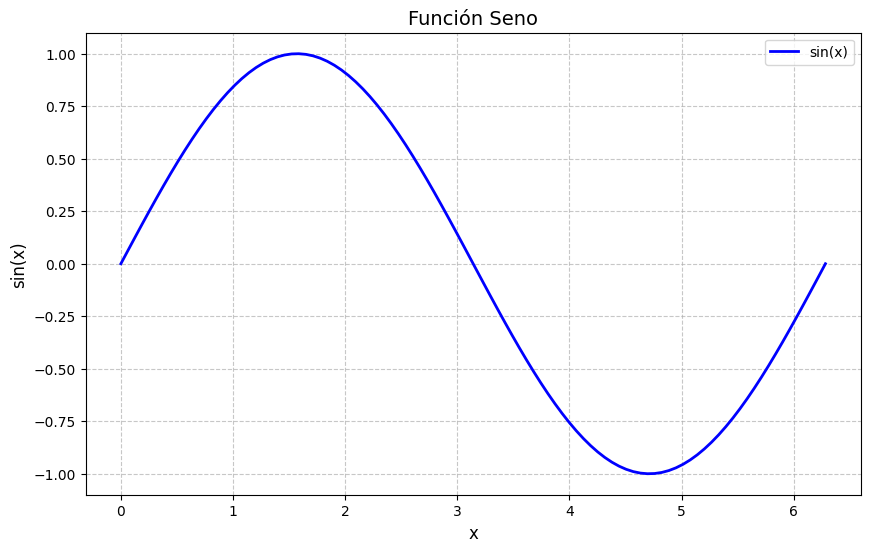

In [42]:
# ============================================================
# MATLAB:  x = 0:0.1:2*pi;
#          y = sin(x);
#          plot(x, y)
#          title('Seno')
#          xlabel('x')
#          ylabel('sin(x)')
#          grid on
#          legend('sin(x)')
# ============================================================

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='sin(x)')  # 'b-' = línea azul
plt.title('Función Seno', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('sin(x)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

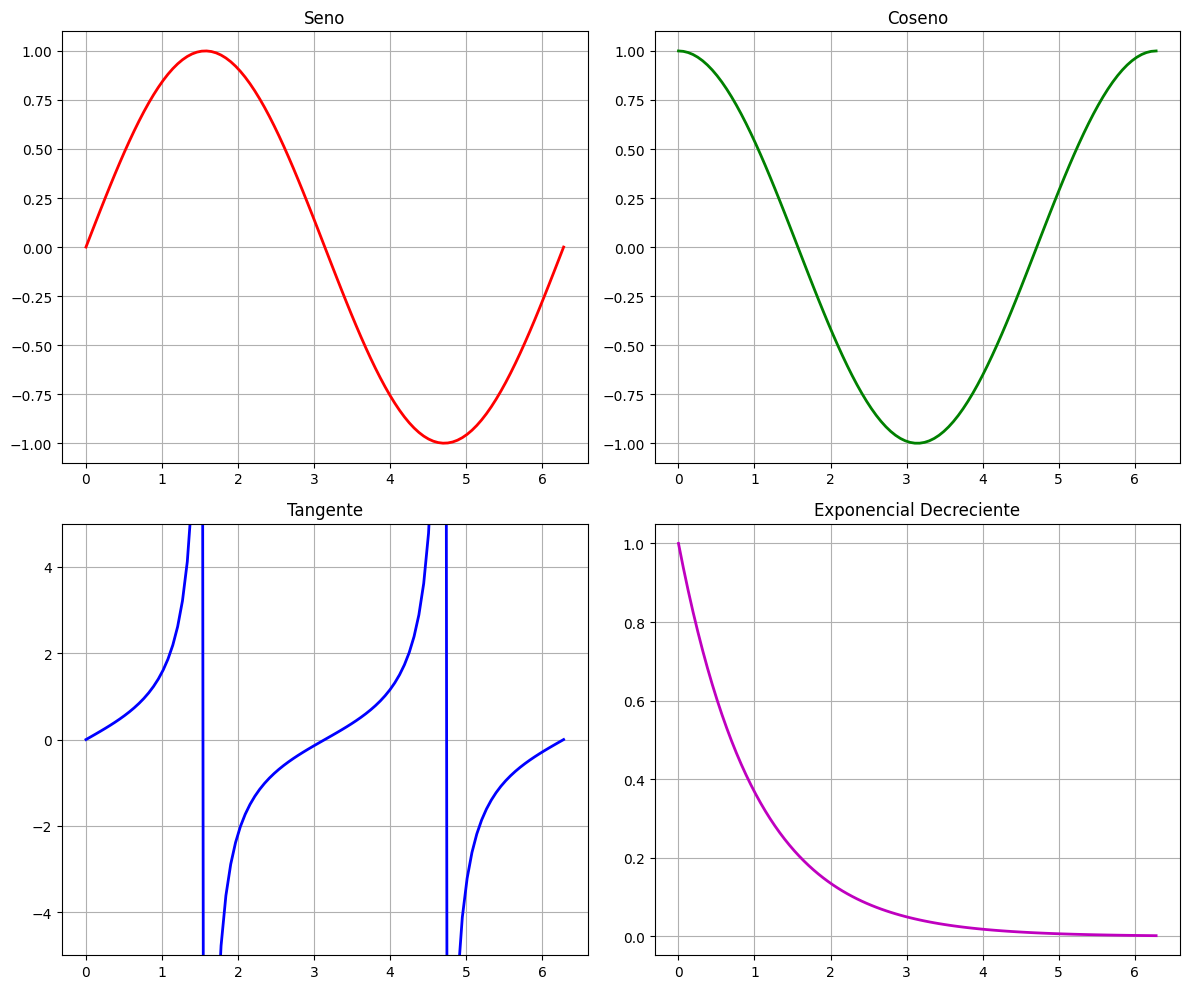

In [43]:
# Múltiples gráficos (subplots) - equivalente a subplot() de MATLAB

# ============================================================
# MATLAB:  subplot(2,2,1)
#          plot(x, sin(x))
#          subplot(2,2,2)
#          plot(x, cos(x))
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = np.linspace(0, 2*np.pi, 100)

# Subplot 1
axes[0, 0].plot(x, np.sin(x), 'r-', linewidth=2)
axes[0, 0].set_title('Seno')
axes[0, 0].grid(True)

# Subplot 2
axes[0, 1].plot(x, np.cos(x), 'g-', linewidth=2)
axes[0, 1].set_title('Coseno')
axes[0, 1].grid(True)

# Subplot 3
axes[1, 0].plot(x, np.tan(x), 'b-', linewidth=2)
axes[1, 0].set_ylim(-5, 5)  # Limitar eje y
axes[1, 0].set_title('Tangente')
axes[1, 0].grid(True)

# Subplot 4
axes[1, 1].plot(x, np.exp(-x), 'm-', linewidth=2)
axes[1, 1].set_title('Exponencial Decreciente')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

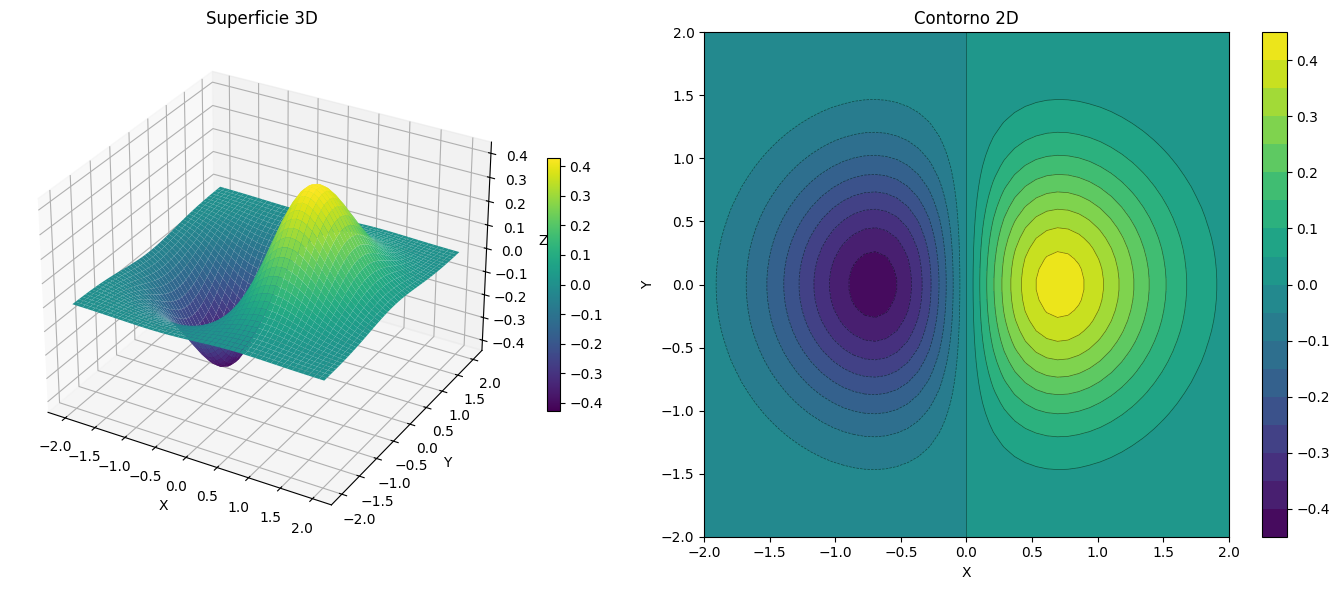

In [44]:
# Gráficos 3D - equivalente a meshgrid, surf, contour de MATLAB

from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# MATLAB:  [X, Y] = meshgrid(-2:0.1:2, -2:0.1:2);
#          Z = X .* exp(-X.^2 - Y.^2);
#          surf(X, Y, Z)
# ============================================================

x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = X * np.exp(-X**2 - Y**2)

fig = plt.figure(figsize=(14, 6))

# Superficie 3D
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax1.set_title('Superficie 3D')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contorno 2D
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5, alpha=0.5)
ax2.set_title('Contorno 2D')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

## 9. Lectura y Almacenamiento de Datos

### Leer y guardar datos desde un archivo de excel

In [153]:
# ============================================================
# MATLAB:
#
# writematrix(matrixA', "../data/matrices.xls", Sheet="MatrixC", Range="B3:K12")
#
# ============================================================
# Python:
# Creamos una matriz de números aleatoriamente
# Matriz A
matrizA = np.random.rand(5, 5)
print(f'matriz A: \n {matrizA} \n')
dfMatrizA = pd.DataFrame(matrizA)
print(f'DataFrame matriz A:\n {dfMatrizA} \n')

# Matriz B
matrizB = np.random.rand(7, 7)
print(f'matriz B: \n {matrizB} \n')
dfMatrizB = pd.DataFrame(matrizB, columns=["H1","H2","H3","H4","H5","H6","H7"])
print(f'DataFrame matriz A:\n {dfMatrizB} \n')

matriz A: 
 [[0.31128385 0.35803286 0.40170099 0.73312327 0.15227763]
 [0.4551134  0.93912798 0.76618034 0.92742834 0.31939008]
 [0.54382854 0.7487643  0.86261559 0.34809697 0.94092949]
 [0.04835403 0.08796296 0.36502776 0.23217162 0.68332914]
 [0.77213723 0.43359873 0.00197664 0.5539862  0.0707366 ]] 

DataFrame matriz A:
           0         1         2         3         4
0  0.311284  0.358033  0.401701  0.733123  0.152278
1  0.455113  0.939128  0.766180  0.927428  0.319390
2  0.543829  0.748764  0.862616  0.348097  0.940929
3  0.048354  0.087963  0.365028  0.232172  0.683329
4  0.772137  0.433599  0.001977  0.553986  0.070737 

matriz B: 
 [[0.19953336 0.53416035 0.81495908 0.4391528  0.84561319 0.02629137
  0.70757321]
 [0.1920109  0.48463442 0.83628009 0.29532577 0.50449219 0.34455131
  0.95653358]
 [0.52294004 0.70670265 0.01562369 0.31144044 0.63882354 0.43236543
  0.70472202]
 [0.25209539 0.73335953 0.33712592 0.29858672 0.64828499 0.97415854
  0.80611688]
 [0.78667829 0.31287

In [151]:
with pd.ExcelWriter("matrices.xlsx") as writer:
    dfMatrizA.to_excel(writer, sheet_name='matriz A', index=False, header=False, startrow=0, startcol=0)
    dfMatrizB.to_excel(writer, sheet_name='matriz B', index=True, header=True, startrow=4, startcol=5)

In [150]:
# ============================================================
# MATLAB:
#
# readedMatrixC = readmatrix("../data/matrices.xls", Sheet="MatrixC", Range="B3:K12")
#
# ============================================================
# Python:
# Leer Matriz de datos desde Excel
print("Dataframe ===============================================================")
leerMatrizA = pd.read_excel("matrices.xlsx", sheet_name='matriz A',header=None)
print(f"Matriz A: \n {leerMatrizA}\n")

# Convertir matriz de datos a arreglo numérico
print("Array de Numpy ===============================================================")
arrayMatrizA = leerMatrizA.to_numpy()
print(f'Matriz A:\n {arrayMatrizA} \n')

# Leer Matriz de datos desde Excel
print("Dataframe ===============================================================")
leerMatrizB = pd.read_excel("matrices.xlsx", sheet_name="matriz B", header=None, usecols="G:M", skiprows=5)
print(f"Matriz B:\n {leerMatrizB} \n")

# Convertir matriz de datos a arreglo numérico
print("Array de Numpy ===============================================================")
arrayMatrizB = leerMatrizB.to_numpy()
print(f'Matriz B:\n {arrayMatrizB} \n')


Dataframe ===============================================================
Matriz A: 
           0         1         2         3         4
0  0.134294  0.578506  0.733236  0.120781  0.970324
1  0.951661  0.088498  0.033046  0.294643  0.048985
2  0.995790  0.397589  0.573935  0.345353  0.957576
3  0.032804  0.588877  0.868642  0.946292  0.946892
4  0.452104  0.820463  0.861134  0.778438  0.216577

Array de Numpy ===============================================================
Matriz A:
 [[0.13429414 0.57850593 0.73323593 0.12078143 0.97032374]
 [0.95166095 0.08849837 0.03304638 0.29464275 0.04898479]
 [0.99579006 0.39758859 0.57393454 0.34535328 0.95757649]
 [0.03280408 0.58887727 0.86864195 0.94629187 0.9468924 ]
 [0.45210367 0.82046314 0.86113368 0.77843756 0.2165766 ]] 

Dataframe ===============================================================
Matriz B:
          6         7         8         9         10        11        12
0  0.153196  0.057543  0.437339  0.945346  0.552555  0.939399

### Leer datos desde un archivo CSV

In [128]:
# ============================================================
# MATLAB:
#
# fid1 = fopen('lancha2_221016211519_X1548.csv', 'r')
# for j=1:64
#     s = fgetl(fid1)
# end
# for j=65:18522
#     currentLine = fgetl(fid1);
#     data = strsplit(currentLine, ',');
#     time(j)=datetime(data{1}, "InputFormat","yyyy/MM/dd HH:mm:ss");
#     p(j)=str2double(data{2}); %cm
#     t(j)=str2double(data{3}); %C
#     cond(j)=str2double(data{4}); %mS/cm
# end
# fclose(fid1);
# ============================================================
# Python:
# Leer archivo (pandas detecta automáticamente fechas y números)
df = pd.read_csv(
    'lancha2_221016211519_X1548.csv',
    skiprows=64,           # Saltar primeras 64 líneas (headers/metadata)
    header=None,           # Sin encabezados en la línea 65
    names=['datetime', 'p', 't', 'cond'],  # Nombres de columnas
    parse_dates=['datetime'],  # Convertir primera columna a datetime
    date_format='%Y/%m/%d %H:%M:%S',  # Formato de fecha
    encoding='latin-1'
)

# Renombrar para coincidir con tu código MATLAB
time = df['datetime'].values
p = df['p'].values      # cm
t = df['t'].values      # °C
cond = df['cond'].values  # mS/cm

print(f"✓ Leídos {len(time)} registros")

✓ Leídos 18459 registros


## 🎯 Resumen de Diferencias Clave

### Lo que debes recordar:

1. **Indexación base-0 vs base-1**
   - Python: `A[0]` es el primer elemento
   - MATLAB: `A(1)` es el primer elemento

2. **Operadores de multiplicación**
   - Python: `*` es elemento a elemento, `@` es matricial
   - MATLAB: `.*` es elemento a elemento, `*` es matricial

3. **Rangos**
   - Python: `arange(1, 10)` → 1 al 9 (el final es exclusivo)
   - MATLAB: `1:10` → 1 al 10 (el final es inclusivo)

4. **Funciones matemáticas**
   - Python: `np.sin(x)` (requiere import numpy as np)
   - MATLAB: `sin(x)` (funciones built-in)

5. **Comentarios**
   - Python: `# comentario`
   - MATLAB: `% comentario`

6. **Strings**
   - Python: comillas simples o dobles (`'text'` o `"text")
   - MATLAB: comillas simples para char, dobles para string (`'text'` vs `"text")

---

## 📚 Recursos Adicionales

- **NumPy para usuarios de MATLAB**: https://numpy.org/doc/stable/user/numpy-for-matlab-users.html
- **Matplotlib**: https://matplotlib.org/stable/tutorials/index.html
- **SciPy**: https://docs.scipy.org/doc/scipy/tutorial/index.html

---

**¡Felicitaciones!** Ahora tienes las herramientas básicas para migrar de MATLAB a Python. 🚀